# Trend Driver Analysis

This notebook measures how trend changes over time and which variables are most useful for predicting the next move.

It focuses on the current schema and answers:

1. How to express trend as a signed percentage.
2. Which variables are most related to future trend change.
3. Which feature combinations work best.
4. Which indicators or patterns have the strongest predictive power.
5. How support and resistance relate to trend direction.

In [ ]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Make app imports work when notebook is opened from notebooks/
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from app.config.database import engine
from app.services.data_storage_service import DataStorageService

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [ ]:
# Set your target symbol/interval here
SYMBOL = "BTCUSDT"
INTERVAL = "1h"
HORIZON_BARS = 6  # candles ahead for future trend measurement
NEUTRAL_BAND_PCT = 0.25
TEST_SPLITS = 3

processed_table = DataStorageService.build_processed_table_name(SYMBOL, INTERVAL)
print(f"Symbol: {SYMBOL.upper()} | Interval: {INTERVAL}")
print(f"Processed table: {processed_table}")
print(f"Prediction horizon: {HORIZON_BARS} bar(s)")
print(f"Neutral band: +/-{NEUTRAL_BAND_PCT:.2f}%")

Symbol: BTCUSDT | Interval: 1h
Processed table: btcusdt_1h_processed
Prediction horizon: 6 bar(s)
Neutral band: +/-0.25%


In [ ]:
def table_columns(table_name: str) -> list[str]:
    query = text(
        """
        SELECT column_name
        FROM information_schema.columns
        WHERE table_schema = 'public' AND table_name = :table_name
        ORDER BY ordinal_position
        """
    )
    with engine.begin() as conn:
        rows = conn.execute(query, {"table_name": table_name}).fetchall()
    return [str(row[0]) for row in rows]


def safe_read_sql(query: str, params: dict | None = None) -> pd.DataFrame:
    with engine.begin() as conn:
        return pd.read_sql(text(query), conn, params=params)


candidate_cols = [
    "open_time",
    "open_time_ms",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "support",
    "resistance",
    "trend_pct_change",
    "ma_20",
    "ema_12",
    "ema_26",
    "macd",
    "macd_signal",
    "macd_hist",
    "adx_14",
    "rsi_14",
    "stoch_k_14",
    "stoch_d_3",
    "cci_20",
    "atr_14",
    "vix",
    "obv",
    "vwap",
    "mfi_14",
    "ad_line",
    "volume_oscillator",
    "candle_pattern_1",
    "candle_pattern_2",
    "candle_pattern_3",
    "candle_pattern_complex",
]

existing_cols = table_columns(processed_table)
select_cols = [col for col in candidate_cols if col in existing_cols]
if "open_time_ms" not in select_cols:
    select_cols.insert(0, "open_time_ms")
if "open_time" not in select_cols and "open_time_ms" in existing_cols:
    select_cols.insert(0, "open_time")

query = text(f"SELECT {', '.join(select_cols)} FROM {processed_table} ORDER BY open_time_ms")
df = pd.read_sql(query, engine)

if df.empty:
    raise ValueError(f"No rows found in table: {processed_table}. Check SYMBOL/INTERVAL and pipeline output.")

if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"], errors="coerce", utc=True)
if "open_time_ms" in df.columns:
    df["open_time_utc"] = pd.to_datetime(df["open_time_ms"], unit="ms", errors="coerce", utc=True)

for c in ["open", "high", "low", "close", "volume", "support", "resistance", "trend_pct_change", "ma_20", "ema_12", "ema_26", "macd", "macd_signal", "macd_hist", "adx_14", "rsi_14", "stoch_k_14", "stoch_d_3", "cci_20", "atr_14", "vix", "obv", "vwap", "mfi_14", "ad_line", "volume_oscillator"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

pattern_cols = [c for c in ["candle_pattern_1", "candle_pattern_2", "candle_pattern_3", "candle_pattern_complex"] if c in df.columns]
for c in pattern_cols:
    df[c] = df[c].astype("string")

print(f"Loaded rows: {len(df):,} from {processed_table}")
print(f"Available columns: {len(df.columns)}")
df.head()

Loaded rows: 75,768 from btcusdt_1h_processed
Available columns: 33


,open_time,open_time_ms,open,high,low,close,volume,support,resistance,trend_pct_change,ma_20,ema_12,ema_26,macd,macd_signal,macd_hist,adx_14,rsi_14,stoch_k_14,stoch_d_3,cci_20,atr_14,vix,obv,vwap,mfi_14,ad_line,volume_oscillator,candle_pattern_1,candle_pattern_2,candle_pattern_3,candle_pattern_complex,open_time_utc
0,2017-08-17 04:00:00+00:00,1502942400000,4261.48,4313.62,4261.32,4308.83,47.181009,4261.32,4313.62,1.111116,4308.830000,4308.830000,4308.830000,0.000000,0.000000,0.000000,NaN,NaN,90.841300,90.841300,NaN,52.300000,NaN,0.000000,4294.590000,NaN,38.538675,0.000000,<NA>,<NA>,<NA>,<NA>,2017-08-17 04:00:00+00:00
1,2017-08-17 05:00:00+00:00,1502946000000,4308.83,4328.69,4291.37,4315.32,23.234916,4261.32,4328.69,0.150621,4312.075000,4309.828462,4309.310741,0.517721,0.103544,0.414177,100.000000,NaN,80.154371,85.497836,133.333333,51.230000,NaN,23.234916,4300.266528,NaN,45.125637,-3.385400,<NA>,<NA>,<NA>,<NA>,2017-08-17 05:00:00+00:00
2,2017-08-17 06:00:00+00:00,1502949600000,4330.29,4345.45,4309.37,4324.35,7.229691,4261.32,4345.45,-0.137173,4316.166667,4312.062544,4310.424760,1.637784,0.410392,1.227392,100.000000,NaN,74.919767,81.971813,128.519656,50.147857,NaN,30.464607,4302.698921,NaN,43.899314,-8.862865,<NA>,<NA>,<NA>,<NA>,2017-08-17 06:00:00+00:00
3,2017-08-17 07:00:00+00:00,1502953200000,4316.62,4349.99,4287.41,4349.99,4.443249,4261.32,4349.99,0.773059,4324.622500,4317.897538,4313.355518,4.542019,1.236718,3.305301,93.789913,NaN,100.000000,85.024713,96.526433,51.035867,NaN,34.907856,4304.129564,NaN,48.342563,-14.337424,<NA>,Bullish Engulfing,<NA>,<NA>,2017-08-17 07:00:00+00:00
4,2017-08-17 08:00:00+00:00,1502956800000,4333.32,4377.85,4333.32,4360.69,0.972807,4261.32,4377.85,0.631617,4331.836000,4324.480993,4316.861776,7.619217,2.513217,5.105999,90.337385,NaN,85.274178,86.731315,156.660768,50.571163,NaN,35.880663,4304.752133,NaN,48.565612,-20.056706,<NA>,<NA>,<NA>,<NA>,2017-08-17 08:00:00+00:00


In [ ]:
def signed_pct_change(series_a: pd.Series, series_b: pd.Series) -> pd.Series:
    base = pd.to_numeric(series_a, errors="coerce").replace(0, np.nan)
    compare = pd.to_numeric(series_b, errors="coerce")
    return ((compare - base) / base) * 100.0


analysis_df = df.copy().sort_values("open_time_ms").reset_index(drop=True)

# Current candle trend as a signed percentage.
analysis_df["current_trend_pct"] = signed_pct_change(analysis_df["open"], analysis_df["close"])

# Future trend target over the selected horizon.
analysis_df["future_close"] = analysis_df["close"].shift(-HORIZON_BARS)
analysis_df["future_trend_pct"] = signed_pct_change(analysis_df["close"], analysis_df["future_close"])
analysis_df["future_trend_direction"] = np.select(
    [analysis_df["future_trend_pct"] > NEUTRAL_BAND_PCT, analysis_df["future_trend_pct"] < -NEUTRAL_BAND_PCT],
    [1, -1],
    default=0,
)

# Useful derived variables for reasoning about why trend changes.
analysis_df["body_pct"] = signed_pct_change(analysis_df["open"], analysis_df["close"])
analysis_df["range_pct"] = signed_pct_change(analysis_df["low"], analysis_df["high"])
analysis_df["upper_wick_pct"] = ((pd.to_numeric(analysis_df["high"], errors="coerce") - pd.to_numeric(analysis_df["close"], errors="coerce")) / pd.to_numeric(analysis_df["close"], errors="coerce").replace(0, np.nan)) * 100.0
analysis_df["lower_wick_pct"] = ((pd.to_numeric(analysis_df["open"], errors="coerce") - pd.to_numeric(analysis_df["low"], errors="coerce")) / pd.to_numeric(analysis_df["open"], errors="coerce").replace(0, np.nan)) * 100.0

if {"support", "resistance"}.issubset(analysis_df.columns):
    analysis_df["support_distance_pct"] = signed_pct_change(analysis_df["support"], analysis_df["close"])
    analysis_df["resistance_distance_pct"] = signed_pct_change(analysis_df["close"], analysis_df["resistance"])
else:
    analysis_df["support_distance_pct"] = np.nan
    analysis_df["resistance_distance_pct"] = np.nan

analysis_df = analysis_df.dropna(subset=["future_trend_pct"]).reset_index(drop=True)

print(f"Analysis rows: {len(analysis_df):,}")
display(
    analysis_df[[c for c in ["open_time_utc", "open", "close", "current_trend_pct", "future_trend_pct", "future_trend_direction"] if c in analysis_df.columns]].head(10)
)

Analysis rows: 75,723


,open_time_utc,open,close,current_trend_pct,future_trend_pct,future_trend_direction
0,2017-08-17 04:00:00+00:00,4261.48,4308.83,1.111116,3.508377,1
1,2017-08-17 05:00:00+00:00,4308.83,4315.32,0.150621,2.594941,1
2,2017-08-17 06:00:00+00:00,4330.29,4324.35,-0.137173,2.003769,1
3,2017-08-17 07:00:00+00:00,4316.62,4349.99,0.773059,2.505983,1
4,2017-08-17 08:00:00+00:00,4333.32,4360.69,0.631617,2.525518,1
5,2017-08-17 09:00:00+00:00,4360.00,4444.00,1.926606,-2.062556,-1
6,2017-08-17 10:00:00+00:00,4441.10,4460.00,0.425570,-2.372646,-1
7,2017-08-17 11:00:00+00:00,4460.00,4427.30,-0.733184,-3.118379,-1
8,2017-08-17 12:00:00+00:00,4436.06,4411.00,-0.564916,-3.491952,-1
9,2017-08-17 13:00:00+00:00,4411.00,4459.00,1.088189,-3.000000,-1


In [ ]:
numeric_feature_candidates = [
    "current_trend_pct",
    "body_pct",
    "range_pct",
    "upper_wick_pct",
    "lower_wick_pct",
    "support_distance_pct",
    "resistance_distance_pct",
    "trend_pct_change",
    "ma_20",
    "ema_12",
    "ema_26",
    "macd",
    "macd_signal",
    "macd_hist",
    "adx_14",
    "rsi_14",
    "stoch_k_14",
    "stoch_d_3",
    "cci_20",
    "atr_14",
    "vix",
    "obv",
    "vwap",
    "mfi_14",
    "ad_line",
    "volume_oscillator",
    "volume",
]

available_numeric_features = [c for c in numeric_feature_candidates if c in analysis_df.columns]
pattern_text_cols = [c for c in ["candle_pattern_1", "candle_pattern_2", "candle_pattern_3", "candle_pattern_complex"] if c in analysis_df.columns]

feature_groups = {
    "price_action": [c for c in ["current_trend_pct", "body_pct", "range_pct", "upper_wick_pct", "lower_wick_pct", "volume"] if c in analysis_df.columns],
    "trend_context": [c for c in ["support_distance_pct", "resistance_distance_pct", "trend_pct_change"] if c in analysis_df.columns],
    "indicators": [c for c in ["ma_20", "ema_12", "ema_26", "macd", "macd_signal", "macd_hist", "adx_14", "rsi_14", "stoch_k_14", "stoch_d_3", "cci_20", "atr_14", "vix", "obv", "vwap", "mfi_14", "ad_line", "volume_oscillator"] if c in analysis_df.columns],
    "patterns": pattern_text_cols,
    "all_numeric": available_numeric_features,
    "all_features": available_numeric_features + pattern_text_cols,
}

for group_name, cols in feature_groups.items():
    seen = set()
    deduped = []
    for col in cols:
        if col not in seen:
            deduped.append(col)
            seen.add(col)
    feature_groups[group_name] = deduped


def make_xy(df: pd.DataFrame, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.Series]:
    frame = df.copy()
    categorical_cols = [c for c in feature_cols if c in pattern_text_cols]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    X = frame[numeric_cols].copy()
    if categorical_cols:
        pattern_frame = pd.get_dummies(frame[categorical_cols], columns=categorical_cols, dummy_na=True, prefix_sep="__")
        X = pd.concat([X, pattern_frame], axis=1)

    y = frame["future_trend_direction"].astype(int)
    mask = y.notna()
    X = X.loc[mask].reset_index(drop=True)
    y = y.loc[mask].reset_index(drop=True)
    return X, y


def evaluate_group(df: pd.DataFrame, feature_cols: list[str], model_name: str = "logistic") -> dict:
    X, y = make_xy(df, feature_cols)

    # Adaptive split count so smaller datasets still produce valid metrics.
    if len(X) < 45 or y.nunique() < 2:
        return {
            "rows": len(X),
            "splits_used": np.nan,
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_macro": np.nan,
        }

    n_splits = min(TEST_SPLITS, 5, max(2, len(X) // 45))
    tscv = TimeSeriesSplit(n_splits=n_splits)
    metrics = []

    if model_name == "logistic":
        estimator = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=2000, solver="lbfgs", class_weight="balanced")),
            ]
        )
    elif model_name == "forest":
        estimator = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(n_estimators=80, max_depth=8, min_samples_leaf=30, class_weight="balanced_subsample", n_jobs=-1, random_state=42)),
            ]
        )
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        estimator.fit(X_train, y_train)
        y_pred = estimator.predict(X_test)

        metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        })

    summary = pd.DataFrame(metrics).mean(numeric_only=True).to_dict()
    summary["rows"] = len(X)
    summary["splits_used"] = n_splits
    return summary

In [ ]:
results = []
for group_name, cols in feature_groups.items():
    logistic_result = evaluate_group(analysis_df, cols, model_name="logistic")
    forest_result = evaluate_group(analysis_df, cols, model_name="forest")

    results.append({"feature_group": group_name, "model": "logistic", **logistic_result})
    results.append({"feature_group": group_name, "model": "forest", **forest_result})

results_df = pd.DataFrame(results).sort_values(["balanced_accuracy", "f1_macro"], ascending=False)
display(results_df)

best_row = results_df.iloc[0]
print(
    f"Best combo so far: {best_row['feature_group']} with {best_row['model']} | "
    f"balanced_accuracy={best_row['balanced_accuracy']:.4f}, f1_macro={best_row['f1_macro']:.4f}, accuracy={best_row['accuracy']:.4f}"
)

,feature_group,model,accuracy,balanced_accuracy,f1_macro,rows,splits_used
3,trend_context,forest,0.378095,0.398589,0.368008,75723,3
1,price_action,forest,0.364342,0.397011,0.351011,75723,3
9,all_numeric,forest,0.379503,0.383802,0.334095,75723,3
2,trend_context,logistic,0.336591,0.382292,0.305652,75723,3
11,all_features,forest,0.378676,0.381949,0.328844,75723,3
0,price_action,logistic,0.316552,0.374844,0.270683,75723,3
10,all_features,logistic,0.369202,0.367313,0.331058,75723,3
4,indicators,logistic,0.366050,0.367174,0.328883,75723,3
8,all_numeric,logistic,0.368410,0.366589,0.329001,75723,3
5,indicators,forest,0.371562,0.361963,0.303542,75723,3


Best combo so far: trend_context with forest | balanced_accuracy=0.3986, f1_macro=0.3680, accuracy=0.3781


,feature,mutual_info
2,trend_pct_change,0.014923
1,resistance_distance_pct,0.013039
0,support_distance_pct,0.012591


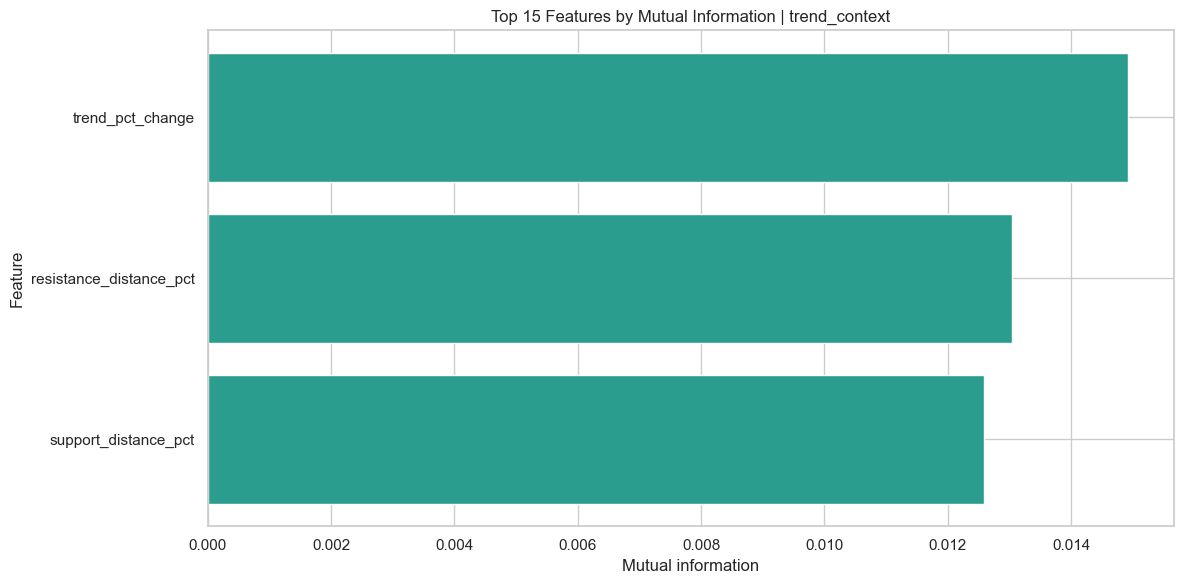

Best feature group: trend_context
Best model: forest
Best accuracy: 0.3781
Best balanced accuracy: 0.3986
Best macro F1: 0.368
Splits used: 3


In [ ]:
best_group_name = str(best_row["feature_group"])
best_group_cols = feature_groups[best_group_name]
X_best, y_best = make_xy(analysis_df, best_group_cols)

imputer = SimpleImputer(strategy="median")
X_best_imputed = imputer.fit_transform(X_best)
feature_names = list(X_best.columns)

mi_scores = mutual_info_classif(X_best_imputed, y_best, random_state=42)
mi_df = pd.DataFrame({"feature": feature_names, "mutual_info": mi_scores}).sort_values("mutual_info", ascending=False)

display(mi_df.head(20))

fig, ax = plt.subplots(figsize=(12, 6))
plot_df = mi_df.head(15).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["mutual_info"], color="#2a9d8f")
ax.set_title(f"Top 15 Features by Mutual Information | {best_group_name}")
ax.set_xlabel("Mutual information")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Best feature group:", best_group_name)
print("Best model:", best_row["model"])
print("Best accuracy:", round(float(best_row["accuracy"]), 4))
print("Best balanced accuracy:", round(float(best_row["balanced_accuracy"]), 4))
print("Best macro F1:", round(float(best_row["f1_macro"]), 4))
print("Splits used:", int(best_row["splits_used"]) if pd.notna(best_row["splits_used"]) else None)

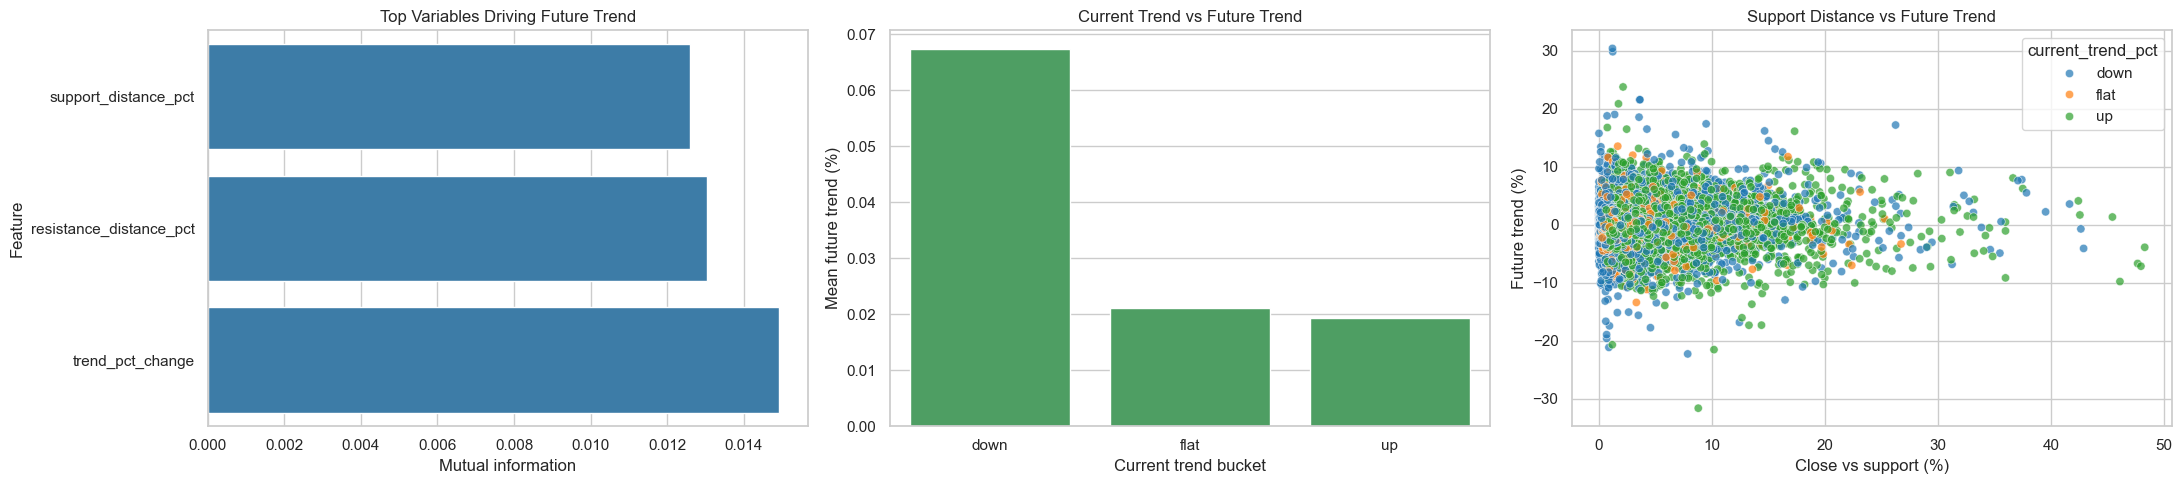

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Top variables linked to future trend movement.
plot_top = mi_df.head(12).sort_values("mutual_info", ascending=True)
sns.barplot(data=plot_top, x="mutual_info", y="feature", ax=axes[0], color="#2C7FB8")
axes[0].set_title("Top Variables Driving Future Trend")
axes[0].set_xlabel("Mutual information")
axes[0].set_ylabel("Feature")

# Average future trend by sign of current trend.
summary_trend = analysis_df.groupby(pd.cut(analysis_df["current_trend_pct"], bins=[-np.inf, -0.1, 0.1, np.inf], labels=["down", "flat", "up"]))["future_trend_pct"].mean().reset_index()
sns.barplot(data=summary_trend, x="current_trend_pct", y="future_trend_pct", ax=axes[1], color="#41AB5D")
axes[1].set_title("Current Trend vs Future Trend")
axes[1].set_xlabel("Current trend bucket")
axes[1].set_ylabel("Mean future trend (%)")

# Trend vs support/resistance distance.
if {"support_distance_pct", "resistance_distance_pct"}.issubset(analysis_df.columns):
    scatter_df = analysis_df[["current_trend_pct", "future_trend_pct", "support_distance_pct", "resistance_distance_pct"]].dropna()
    if not scatter_df.empty:
        sns.scatterplot(
            data=scatter_df,
            x="support_distance_pct",
            y="future_trend_pct",
            hue=pd.cut(scatter_df["current_trend_pct"], bins=[-np.inf, -0.1, 0.1, np.inf], labels=["down", "flat", "up"]),
            ax=axes[2],
            palette="tab10",
            alpha=0.7,
        )
        axes[2].set_title("Support Distance vs Future Trend")
        axes[2].set_xlabel("Close vs support (%)")
        axes[2].set_ylabel("Future trend (%)")
    else:
        axes[2].text(0.5, 0.5, "No support/resistance data", ha="center", va="center")
        axes[2].set_axis_off()
else:
    axes[2].text(0.5, 0.5, "Support/resistance columns not available", ha="center", va="center")
    axes[2].set_axis_off()

plt.tight_layout()
plt.show()